In [33]:
import pandas as pd

In [34]:
import sqlalchemy as db
from sqlalchemy import text 
import matplotlib.pyplot as plt


In [35]:
df = pd.read_csv('train_data.csv')

In [36]:
engine = db.create_engine('sqlite:///mydb2.db')

In [37]:
conn = engine.connect()

In [38]:
df.to_sql(name="train_data",con=engine)

ValueError: Table 'train_data' already exists.

In [ ]:
#ПОЛ
women_survived = conn.execute(text("SELECT COUNT(sex) FROM train_data WHERE survived = 1 AND sex = 0")).fetchall()[0][0]
women_total = conn.execute(text("SELECT COUNT(sex) FROM train_data WHERE sex = 0")).fetchall()[0][0]
women_rate = round(women_survived / women_total * 100, 1)

men_survived = conn.execute(text("SELECT COUNT(sex) FROM train_data WHERE survived = 1 AND sex = 1")).fetchall()[0][0]
men_total = conn.execute(text("SELECT COUNT(sex) FROM train_data WHERE sex = 1")).fetchall()[0][0]
men_rate = round(men_survived / men_total * 100, 1)

print(f"Женщины: выжило {women_survived} из {women_total} ({women_rate}%)")
print(f"Мужчины: выжило {men_survived} из {men_total} ({men_rate}%)")


Женщины: выжило 209 из 279 (74.9%)
Мужчины: выжило 97 из 513 (18.9%)


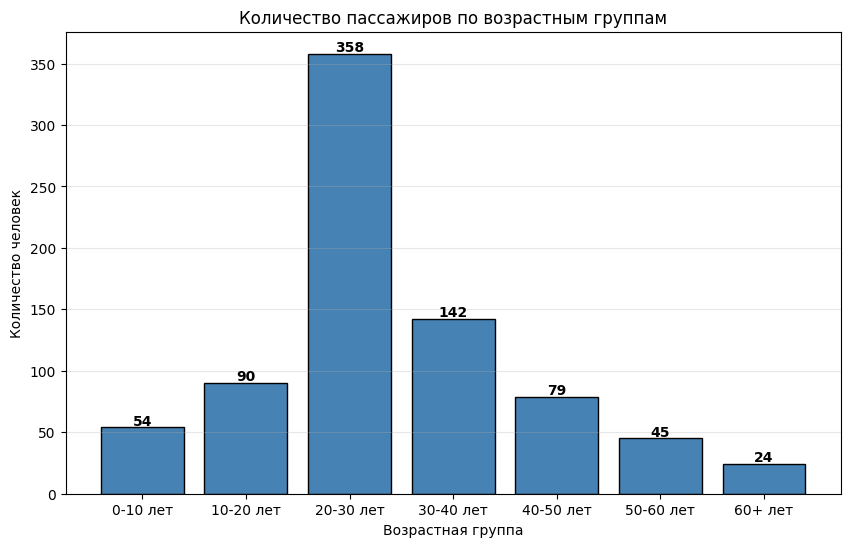

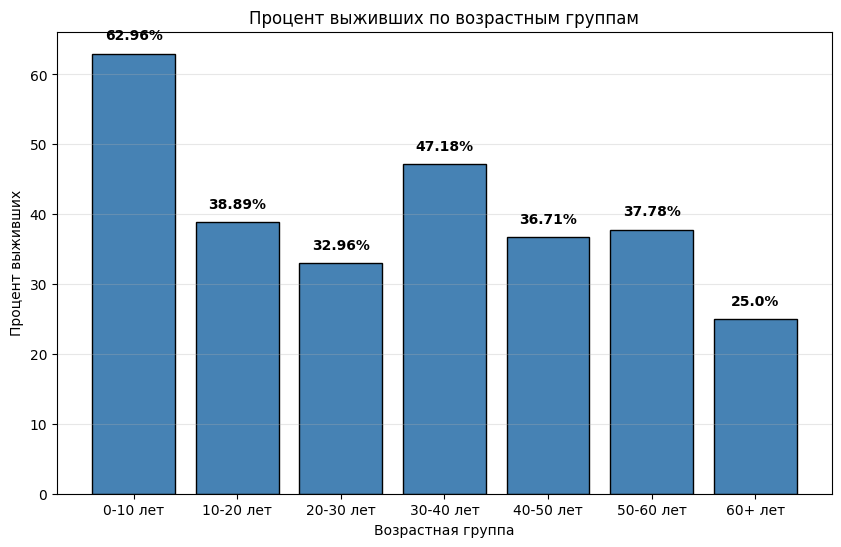

Группа, Всего, Выжило, Процент
0-10 лет | 54 | 34 | 62.96%
Группа, Всего, Выжило, Процент
10-20 лет | 90 | 35 | 38.89%
Группа, Всего, Выжило, Процент
20-30 лет | 358 | 118 | 32.96%
Группа, Всего, Выжило, Процент
30-40 лет | 142 | 67 | 47.18%
Группа, Всего, Выжило, Процент
40-50 лет | 79 | 29 | 36.71%
Группа, Всего, Выжило, Процент
50-60 лет | 45 | 17 | 37.78%
Группа, Всего, Выжило, Процент
60+ лет | 24 | 6 | 25.00%


In [ ]:
#ВОЗРАСТ
query = text("""
    SELECT 
        CASE 
            WHEN age < 0.125 THEN '0-10 лет'
            WHEN age < 0.25 THEN '10-20 лет'
            WHEN age < 0.375 THEN '20-30 лет'
            WHEN age < 0.5 THEN '30-40 лет'
            WHEN age < 0.625 THEN '40-50 лет'
            WHEN age < 0.75 THEN '50-60 лет'
            ELSE '60+ лет'
        END as age_group,
        COUNT(*) as count,
        SUM(survived) as survived
    FROM train_data
    WHERE age IS NOT NULL
    GROUP BY age_group
""")

data = conn.execute(query).fetchall()

groups = [row[0] for row in data]
counts = [row[1] for row in data]
survived_rate = [round(row[2]/row[1]*100,2) for row in data]

plt.figure(figsize=(10, 6))
plt.bar(groups, counts, color='steelblue', edgecolor='black')
plt.xlabel('Возрастная группа')
plt.ylabel('Количество человек')
plt.title('Количество пассажиров по возрастным группам')
plt.grid(axis='y', alpha=0.3)

for i, v in enumerate(counts):
    plt.text(i, v + 2, str(v), ha='center', fontweight='bold')

plt.show()

plt.figure(figsize=(10, 6))
plt.bar(groups, survived_rate, color='steelblue', edgecolor='black')
plt.xlabel('Возрастная группа')
plt.ylabel('Процент выживших')
plt.title('Процент выживших по возрастным группам')
plt.grid(axis='y', alpha=0.3)

for i, v in enumerate(survived_rate):
    plt.text(i, v + 2, str(v)+'%', ha='center', fontweight='bold')

plt.show()

for i, row in enumerate(data):
    group_name = row[0]
    total = row[1]
    survived_count = row[2]
    percent = survived_rate[i]
    print("Группа, Всего, Выжило, Процент")
    print(f"{group_name} | {total} | {survived_count} | {percent:.2f}%")



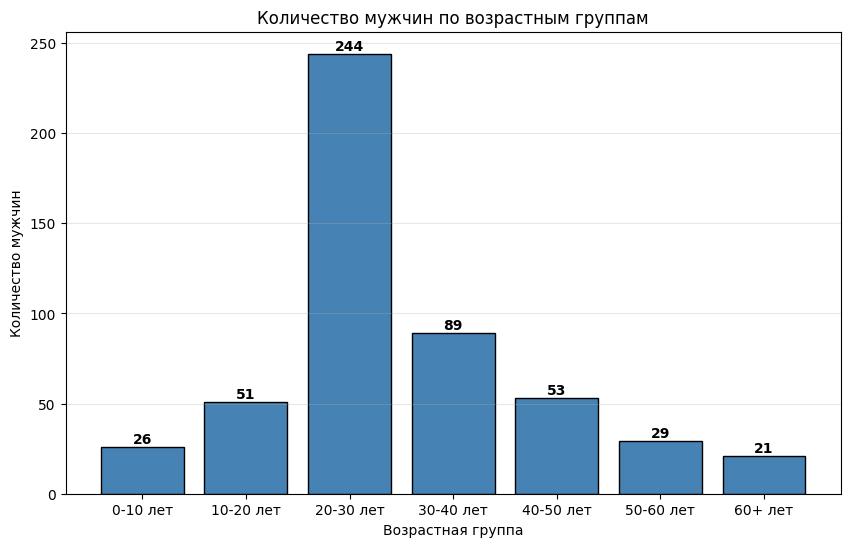

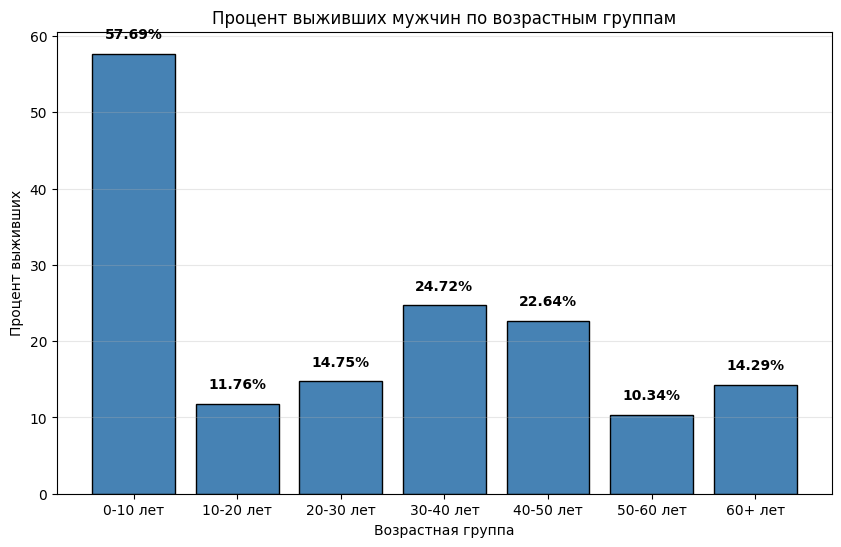

Группа, Всего, Выжило, Процент
0-10 лет | 26 | 15 | 57.69%
Группа, Всего, Выжило, Процент
10-20 лет | 51 | 6 | 11.76%
Группа, Всего, Выжило, Процент
20-30 лет | 244 | 36 | 14.75%
Группа, Всего, Выжило, Процент
30-40 лет | 89 | 22 | 24.72%
Группа, Всего, Выжило, Процент
40-50 лет | 53 | 12 | 22.64%
Группа, Всего, Выжило, Процент
50-60 лет | 29 | 3 | 10.34%
Группа, Всего, Выжило, Процент
60+ лет | 21 | 3 | 14.29%


In [ ]:
#ВОЗРАСТ + МУЖЧИНЫ
query_men_age = text("""
    SELECT 
        CASE 
            WHEN age < 0.125 THEN '0-10 лет'
            WHEN age < 0.25 THEN '10-20 лет'
            WHEN age < 0.375 THEN '20-30 лет'
            WHEN age < 0.5 THEN '30-40 лет'
            WHEN age < 0.625 THEN '40-50 лет'
            WHEN age < 0.75 THEN '50-60 лет'
            ELSE '60+ лет'
        END as age_group,
        COUNT(*) as count,
        SUM(survived) as survived
    FROM train_data
    WHERE age IS NOT NULL AND sex = 1
    GROUP BY age_group
""")

data = conn.execute(query_men_age).fetchall()

groups = [row[0] for row in data]
counts = [row[1] for row in data]
survived_rate = [round(row[2]/row[1]*100,2) for row in data]

plt.figure(figsize=(10, 6))
plt.bar(groups, counts, color='steelblue', edgecolor='black')
plt.xlabel('Возрастная группа')
plt.ylabel('Количество мужчин')
plt.title('Количество мужчин по возрастным группам')
plt.grid(axis='y', alpha=0.3)

for i, v in enumerate(counts):
    plt.text(i, v + 2, str(v), ha='center', fontweight='bold')

plt.show()

plt.figure(figsize=(10, 6))
plt.bar(groups, survived_rate, color='steelblue', edgecolor='black')
plt.xlabel('Возрастная группа')
plt.ylabel('Процент выживших')
plt.title('Процент выживших мужчин по возрастным группам')
plt.grid(axis='y', alpha=0.3)

for i, v in enumerate(survived_rate):
    plt.text(i, v + 2, str(v)+'%', ha='center', fontweight='bold')

plt.show()

for i, row in enumerate(data):
    group_name = row[0]
    total = row[1]
    survived_count = row[2]
    percent = survived_rate[i]
    print("Группа, Всего, Выжило, Процент")
    print(f"{group_name} | {total} | {survived_count} | {percent:.2f}%")

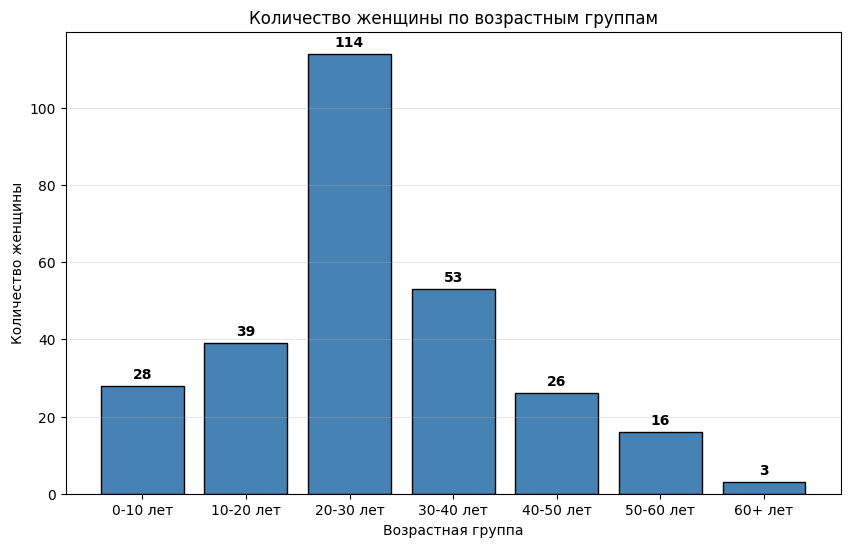

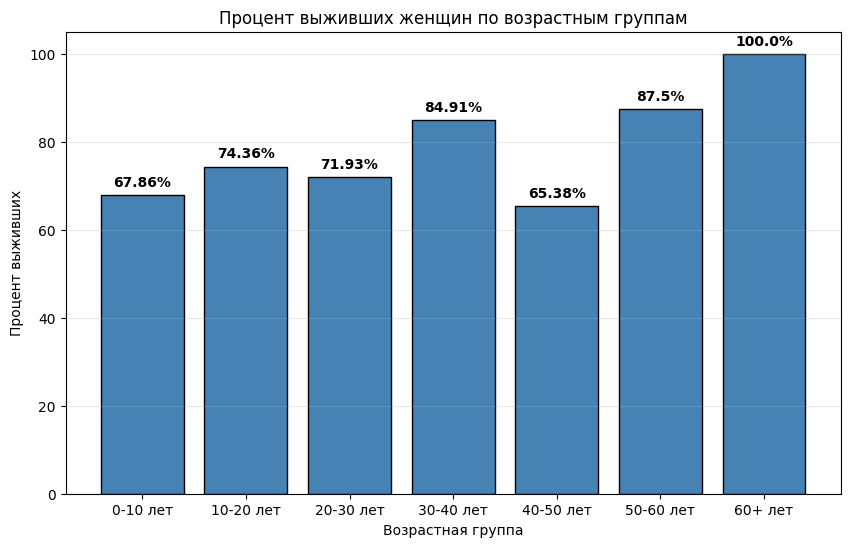

Группа, Всего, Выжило, Процент
0-10 лет | 28 | 19 | 67.86%
Группа, Всего, Выжило, Процент
10-20 лет | 39 | 29 | 74.36%
Группа, Всего, Выжило, Процент
20-30 лет | 114 | 82 | 71.93%
Группа, Всего, Выжило, Процент
30-40 лет | 53 | 45 | 84.91%
Группа, Всего, Выжило, Процент
40-50 лет | 26 | 17 | 65.38%
Группа, Всего, Выжило, Процент
50-60 лет | 16 | 14 | 87.50%
Группа, Всего, Выжило, Процент
60+ лет | 3 | 3 | 100.00%


In [ ]:
# ВОЗРАСТ + ЖЕНЩИНЫ
query_woman_age = text("""
    SELECT 
        CASE 
            WHEN age < 0.125 THEN '0-10 лет'
            WHEN age < 0.25 THEN '10-20 лет'
            WHEN age < 0.375 THEN '20-30 лет'
            WHEN age < 0.5 THEN '30-40 лет'
            WHEN age < 0.625 THEN '40-50 лет'
            WHEN age < 0.75 THEN '50-60 лет'
            ELSE '60+ лет'
        END as age_group,
        COUNT(*) as count,
        SUM(survived) as survived
    FROM train_data
    WHERE age IS NOT NULL AND sex = 0
    GROUP BY age_group
""")

data = conn.execute(query_woman_age).fetchall()

groups = [row[0] for row in data]
counts = [row[1] for row in data]
survived_rate = [round(row[2]/row[1]*100,2) for row in data]

plt.figure(figsize=(10, 6))
plt.bar(groups, counts, color='steelblue', edgecolor='black')
plt.xlabel('Возрастная группа')
plt.ylabel('Количество женщины')
plt.title('Количество женщины по возрастным группам')
plt.grid(axis='y', alpha=0.3)

for i, v in enumerate(counts):
    plt.text(i, v + 2, str(v), ha='center', fontweight='bold')

plt.show()

plt.figure(figsize=(10, 6))
plt.bar(groups, survived_rate, color='steelblue', edgecolor='black')
plt.xlabel('Возрастная группа')
plt.ylabel('Процент выживших')
plt.title('Процент выживших женщин по возрастным группам')
plt.grid(axis='y', alpha=0.3)

for i, v in enumerate(survived_rate):
    plt.text(i, v + 2, str(v)+'%', ha='center', fontweight='bold')

plt.show()

for i, row in enumerate(data):
    group_name = row[0]
    total = row[1]
    survived_count = row[2]
    percent = survived_rate[i]
    print("Группа, Всего, Выжило, Процент")
    print(f"{group_name} | {total} | {survived_count} | {percent:.2f}%")

In [ ]:
#СРЕДНЯЯ ЦЕНА
avg_fare_survived = conn.execute(text("SELECT avg(fare) FROM train_data WHERE survived = 1 ")).fetchall()[0][0]
avg_fare_died = conn.execute(text("SELECT avg(fare) FROM train_data WHERE survived = 0 ")).fetchall()[0][0]

if avg_fare_died < avg_fare_survived:
    print("Бедные умирали чаще")
else: print("Богатые умирали чаще")

print(f"Средняя стоимость билета выживших {avg_fare_survived}")
print(f"Средняя стоимость билета погибших {avg_fare_died}")


Бедные умирали чаще
Средняя стоимость билета выживших 0.09672241592682242
Средняя стоимость билета погибших 0.04450045781231532


Группа, Всего, Выжило, Процент
1. Дешевые (0-0.05) | 498 | 145 | 29.12%
2. Средние (0.05-0.2) | 243 | 124 | 51.03%
3. Дорогие (0.2-0.5) | 42 | 30 | 71.43%
4. Очень дорогие (0.5+) | 9 | 7 | 77.78%


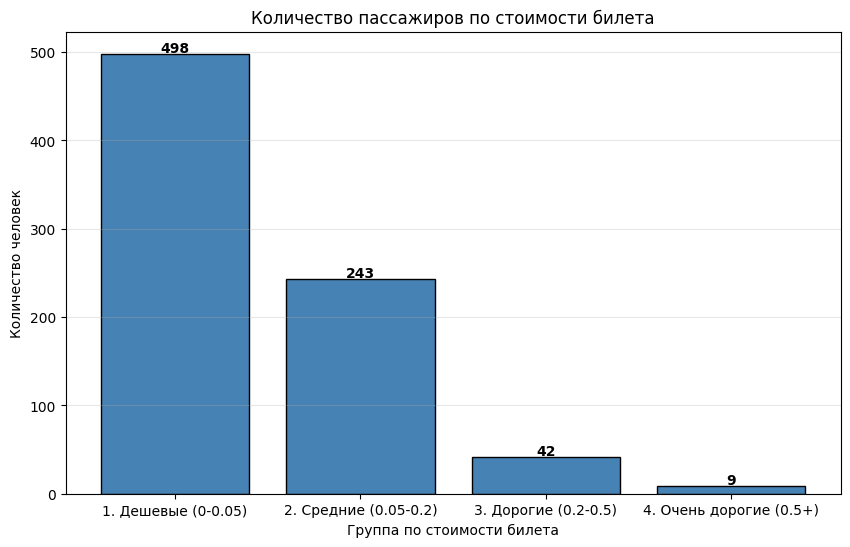

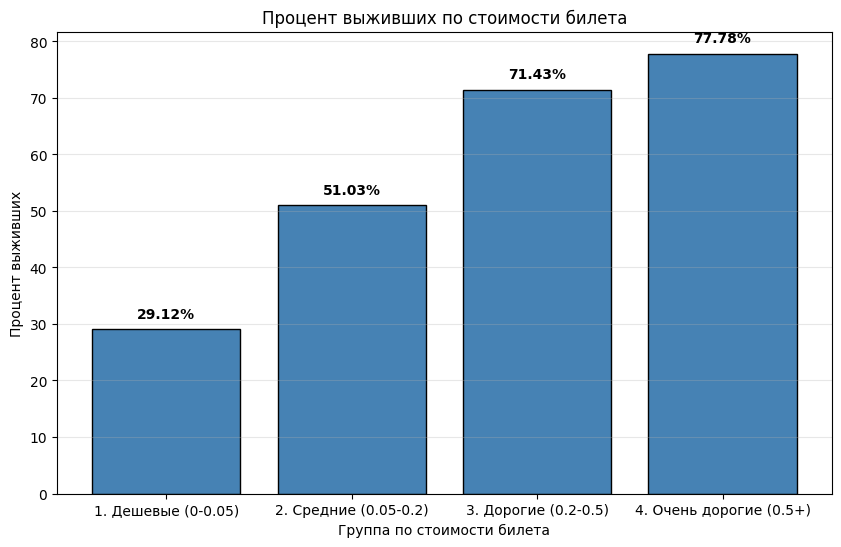

In [ ]:
#ЦЕНА ПО ГРУППАМ
fare_query = text("""
    SELECT 
        CASE 
            WHEN fare < 0.05 THEN '1. Дешевые (0-0.05)'
            WHEN fare < 0.2 THEN '2. Средние (0.05-0.2)'
            WHEN fare < 0.5 THEN '3. Дорогие (0.2-0.5)'
            ELSE '4. Очень дорогие (0.5+)'
        END as fare_group,
        COUNT(*) as count,
        SUM(survived) as survived
    FROM train_data
    WHERE fare IS NOT NULL
    GROUP BY fare_group
""")

fare_data = conn.execute(fare_query).fetchall()

fare_groups = [row[0] for row in fare_data]
fare_counts = [row[1] for row in fare_data]
fare_survived_rate = [round(row[2]/row[1]*100, 2) for row in fare_data]

print("Группа, Всего, Выжило, Процент")
for i, row in enumerate(fare_data):
    group_name = row[0]
    total = row[1]
    survived_count = row[2]
    percent = fare_survived_rate[i]
    print(f"{group_name} | {total} | {survived_count} | {percent:.2f}%")

plt.figure(figsize=(10, 6))
plt.bar(fare_groups, fare_counts, color='steelblue', edgecolor='black')
plt.xlabel('Группа по стоимости билета')
plt.ylabel('Количество человек')
plt.title('Количество пассажиров по стоимости билета')
plt.grid(axis='y', alpha=0.3)

for i, v in enumerate(fare_counts):
    plt.text(i, v + 2, str(v), ha='center', fontweight='bold')

plt.show()

plt.figure(figsize=(10, 6))
plt.bar(fare_groups, fare_survived_rate, color='steelblue', edgecolor='black')
plt.xlabel('Группа по стоимости билета')
plt.ylabel('Процент выживших')
plt.title('Процент выживших по стоимости билета')
plt.grid(axis='y', alpha=0.3)

for i, v in enumerate(fare_survived_rate):
    plt.text(i, v + 2, str(v)+'%', ha='center', fontweight='bold')

plt.show()



Группа, Всего, Выжило, Процент
1 класс | 193 | 119 | 61.66%
2 класс | 165 | 80 | 48.48%
3 класс | 434 | 107 | 24.65%


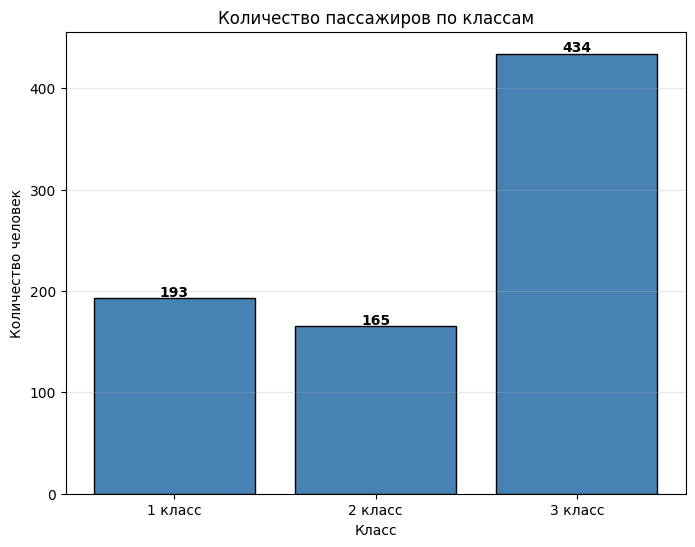

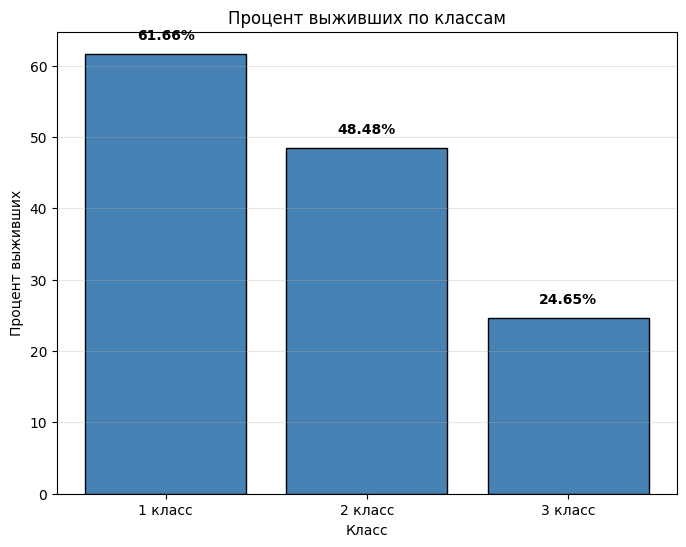

In [ ]:
#КЛАССЫ
class_query = text("""
    SELECT 
        CASE 
            WHEN Pclass_1 = 1 THEN '1 класс'
            WHEN Pclass_2 = 1 THEN '2 класс'
            ELSE '3 класс'
        END as class,
        COUNT(*) as count,
        SUM(survived) as survived
    FROM train_data
    GROUP BY class
    ORDER BY class
""")

class_data = conn.execute(class_query).fetchall()

class_groups = [row[0] for row in class_data]
class_counts = [row[1] for row in class_data]
class_survived_rate = [round(row[2]/row[1]*100, 2) for row in class_data]

print("Группа, Всего, Выжило, Процент")
for i, row in enumerate(class_data):
    class_name = row[0]
    total = row[1]
    survived_count = row[2]
    percent = class_survived_rate[i]
    print(f"{class_name} | {total} | {survived_count} | {percent:.2f}%")

plt.figure(figsize=(8, 6))
plt.bar(class_groups, class_counts, color='steelblue', edgecolor='black')
plt.xlabel('Класс')
plt.ylabel('Количество человек')
plt.title('Количество пассажиров по классам')
plt.grid(axis='y', alpha=0.3)

for i, v in enumerate(class_counts):
    plt.text(i, v + 2, str(v), ha='center', fontweight='bold')

plt.show()

plt.figure(figsize=(8, 6))
plt.bar(class_groups, class_survived_rate, color='steelblue', edgecolor='black')
plt.xlabel('Класс')
plt.ylabel('Процент выживших')
plt.title('Процент выживших по классам')
plt.grid(axis='y', alpha=0.3)

for i, v in enumerate(class_survived_rate):
    plt.text(i, v + 2, str(v)+'%', ha='center', fontweight='bold')

plt.show()

conn.close()